In [114]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

#载入数据，标准化
digits = load_digits()
X, y = digits.data, digits.target

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("X.shape:", X.shape)
print("y.shape:", y.shape)
unique, counts = np.unique(y, return_counts=True)
print("类别分布:", {int(u): int(c) for u, c in zip(unique, counts)})

X.shape: (1797, 64)
y.shape: (1797,)
类别分布: {0: 178, 1: 182, 2: 177, 3: 183, 4: 181, 5: 182, 6: 181, 7: 179, 8: 174, 9: 180}


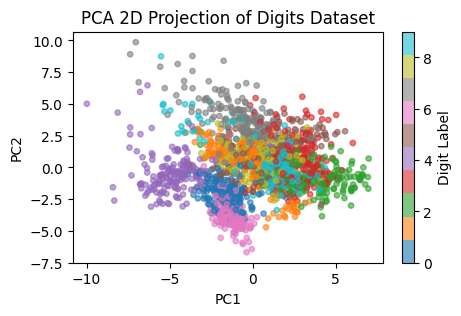

In [115]:
#PCA降维与可视化
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(5, 3))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='tab10', alpha=0.6, s=15)
plt.colorbar(scatter, label='Digit Label')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA 2D Projection of Digits Dataset')
plt.show()

In [116]:
#输出解释方差
print("\nPCA 解释方差比例:")
for i, ratio in enumerate(pca.explained_variance_ratio_):
    print(f"PC{i+1}: {ratio:.4f}")
print(f"累积解释方差: {pca.explained_variance_ratio_.sum():.4f}")


PCA 解释方差比例:
PC1: 0.1203
PC2: 0.0956
累积解释方差: 0.2159


K=5, inertia=85096.05
K=8, inertia=74854.16
K=10, inertia=69813.56
K=12, inertia=65031.72
K=15, inertia=59534.50


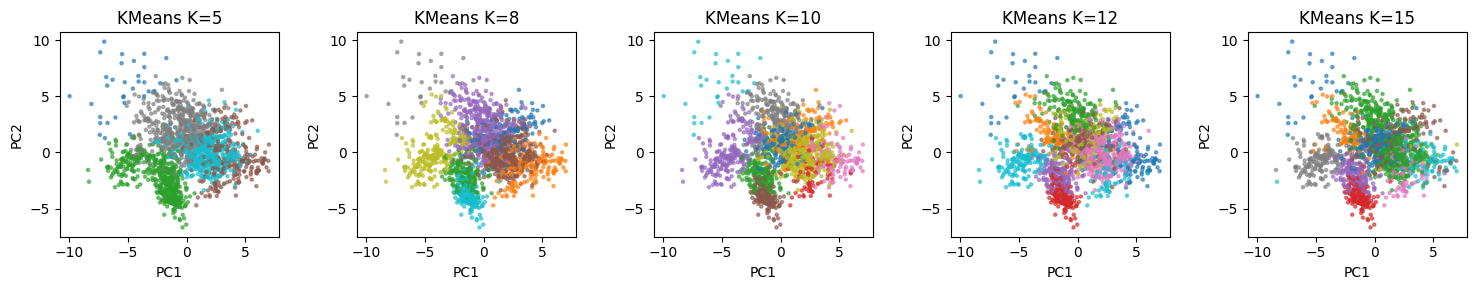

In [117]:
#KMeans聚类
k_values = [5, 8, 10, 12, 15]  # 尝试多个K值
inertias = []

plt.figure(figsize=(15, 3))
for idx, k in enumerate(k_values, 1):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    print(f"K={k}, inertia={kmeans.inertia_:.2f}")

    plt.subplot(1, 5, idx)
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans.labels_, cmap='tab10', alpha=0.6, s=5)
    plt.title(f'KMeans K={k}')
    plt.xlabel('PC1')
    plt.ylabel('PC2')

plt.tight_layout()
plt.show()

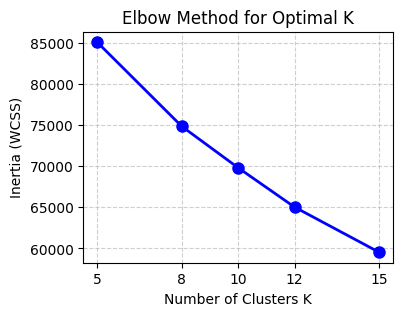


elbow曲线完成，观察拐点位置选择最佳K值


In [118]:
#画选K曲线Elbow
plt.figure(figsize=(4, 3))
plt.plot(k_values, inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters K')
plt.ylabel('Inertia (WCSS)')
plt.title('Elbow Method for Optimal K')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(k_values)
plt.show()

print("\nelbow曲线完成，观察拐点位置选择最佳K值")